# Microwave-optical entanglement

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from src import Transducer, covariance, log_negativity
from src.plots import *
from src.params import *

%config InlineBackend.figure_formats = ['svg']

### Numerics

In [ ]:
def matched_tau(kappa_a, kappa_b, g_s):
    """
    Temporal-mode width matched to the slow-mode ring-down, 1/τ = |λ_crit|.
    """
    return 1.0 / ((kappa_a + kappa_b)/4 - np.sqrt((kappa_a - kappa_b)**2/16 + g_s**2))

# Squeezing cooperativity C = 4|g_s|^2/(kappa_a kappa_b).
C_list = np.linspace(0.0, 0.999, 300) 

# Multiply the matched-tau by a scaling factor if needed.
TAU_SCALE = 0.005

# Number of parallel jobs for computation.
N_JOBS = -1

# Experimental scenarios to plot.
scenarios = {
    'Rochman et al.': ROCHMAN_PARAMS,
    'King et al.': KING_PARAMS,
    # 'Sahu et al.': SAHU_PARAMS,
}

In [57]:
def entanglement_rate(device, g_s, tau):
    """
    Log-negativity per unit time for pure two-mode squeezing (g_t = 0).
    """
    return log_negativity(covariance(device, 0.0, g_s, tau)) / tau

# Entanglement rate vs cooperativity, for each device and out-coupling setting.
ebit_rate = {}
for label, params in scenarios.items():
    for coupling in ('measured', 'ideal'):

        # If ideal, override the measured efficiencies with 1.0.
        p = params if coupling == 'measured' else {**params, 'eta_a': 1.0, 'eta_b': 1.0}

        # Build the transducer device from the parameters.
        device = Transducer.from_params(p, Delta=-p['omega_b'])

        # Set g_s based on the squeezing cooperativity.
        g_s = np.sqrt(C_list * p['kappa_a'] * p['kappa_b']) / 2

        # Set the temporal-mode width tau to a matched value (scales with cooperativity).
        tau = TAU_SCALE * matched_tau(p['kappa_a'], p['kappa_b'], g_s)

        # Compute the entanglement rate for this device and coupling.
        ebit_rate[label, coupling] = np.array(Parallel(n_jobs=N_JOBS)(
            delayed(entanglement_rate)(device, g, t) for g, t in zip(g_s, tau))
            )

### Figure

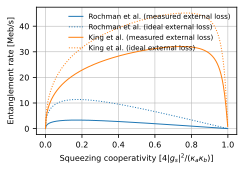

In [58]:
# Figure setup.
fig, ax = plt.subplots(
    figsize = (
        FIG_SIZES['onecol'], 
        0.7 * FIG_SIZES['onecol']
        )
    )

# Color mapping for different scenarios.
colors = {
    'Rochman et al.': 'tab:blue', 
    'King et al.': 'tab:orange', 
    'Sahu et al.': 'tab:green'
    }

# Plot the entanglement rate for each scenario and coupling.
for (label, coupling), rate in ebit_rate.items():
    ax.plot(
        C_list, 
        rate * 2*np.pi * 1e3, 
        color = colors.get(label, 'k'),
        ls = '-' if coupling == 'measured' else ':',
        label = f'{label} ({coupling} external loss)',
        )
    # ax.set_ylim(-0.9, 10.9)

# Set axis labels, grid, and legend.
ax.set(
    xlabel = 'Squeezing cooperativity [$4|g_s|^2/(\\kappa_a \\kappa_b)$]', 
    ylabel = 'Entanglement rate [Meb/s]',
    # title = f'$\\tau \\lambda_{{\\text{{crit}}}} = {TAU_SCALE}$',
)
ax.grid('both')
ax.legend(loc = 'upper right', frameon=False)

# Save figure.
fig.tight_layout()
fig.savefig('fig/entanglement.pdf', bbox_inches='tight')

### $\tau$-matching

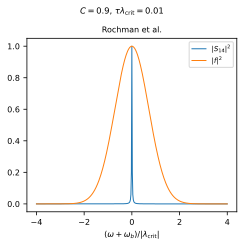

In [ ]:
from src import filter_func

# Set the squeezing cooperativity for this plot.
C = 0.9

# Figure setup.
fig, ax = plt.subplots(
    ncols = len(scenarios),
    nrows = 1,
    figsize = (
        len(scenarios) * FIG_SIZES['onecol'],
        FIG_SIZES['onecol']
        )
    )

# TAU_SCALE = 0.01

# Define the range of detunings from the sideband, in units of |lambda_crit|.
x = np.linspace(-4, 4, 401)

# Loop over the experimental scenarios and plot the emission and filter functions.
for i, (label, p) in enumerate(scenarios.items()):

    if len(scenarios) == 1:
        ax = np.array([ax])

    # Setup transducer.
    device = Transducer.from_params(p, Delta=-p['omega_b'])

    # Calculate the squeezing strength based on the cooperativity.
    g_s = np.sqrt(C * p['kappa_a'] * p['kappa_b']) / 2

    # Determine the temporal-mode width and corresponding lambda.
    tau = TAU_SCALE * matched_tau(p['kappa_a'], p['kappa_b'], g_s)
    lam = 1.0 / tau

    # Compute the emission |S_14|^2.
    emission = np.array(
        [np.abs(device.scattering(-p['omega_b'] + xi * lam, 0.0, g_s)[0][0, 3])**2 for xi in x]
        )
    ax[i].plot(x, emission / emission.max(), label='$|S_{14}|^2$')

    # Compute the filter function |f|^2.
    filter = filter_func(x * lam, tau)**2

    ax[i].plot(x, filter / filter.max(), label='$|f|^2$')

    # Set the axis labels and title for the current subplot.
    ax[i].set(
        xlabel = '$(\\omega + \\omega_b) / |\\lambda_\\mathrm{crit}|$', 
        title = label
        )
    ax[i].legend()

fig.suptitle(f'$C = {C}$, ' + f'$\\tau \\lambda_{{\\text{{crit}}}} = {TAU_SCALE}$')
fig.tight_layout()